# Task Timing Comparison — Alle methoden
Vergelijkt waiting/processing/total time **gemiddeld over episodes** voor alle methoden in een run.

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────
EXPERIMENT_DIR = "../../results/runs/loan_app/earth_d/FINAL_42"

# Which logs to use: "final_eval", "eval", or "train"
LOG_TYPE = "final_eval"

# Set to True to only count working hours (auto-detected from config)
USE_WORKING_TIME = True

# Working hours (auto-detected from experiment config, fallback to these)
WORK_START_HOUR = 7
WORK_END_HOUR = 15

In [ ]:
import os, re

# ── Resolve EXPERIMENT_DIR: auto-pick latest timestamp subfolder ──────
# If the path already ends with a timestamp folder (YYYYMMDD_HHMMSS), use as-is.
# Otherwise, scan for timestamp subfolders and pick the latest one.
def resolve_experiment_dir(path):
    path = path.rstrip("/")
    basename = os.path.basename(path)
    # Check if the path already ends with a timestamp
    if re.match(r"^\d{8}_\d{6}$", basename):
        return path
    # Look for timestamp subfolders
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Directory not found: {path}")
    ts_dirs = sorted(
        [d for d in os.listdir(path)
         if os.path.isdir(os.path.join(path, d)) and re.match(r"^\d{8}_\d{6}$", d)],
    )
    if not ts_dirs:
        # No timestamp subfolders found — use the path as-is
        return path
    latest = ts_dirs[-1]
    print(f"Auto-selected latest run: {latest}")
    return os.path.join(path, latest)

EXPERIMENT_DIR = resolve_experiment_dir(EXPERIMENT_DIR)

In [ ]:
import sys, os, re, glob
import pandas as pd
import numpy as np

sys.path.insert(0, os.path.abspath("../../src"))

if USE_WORKING_TIME:
    from environment.work_schedule import working_seconds_between, configure
    configure(WORK_START_HOUR, WORK_END_HOUR)
    print(f"Working hours configured: {WORK_START_HOUR}:00 - {WORK_END_HOUR}:00")

# ── Timestamp parsing ─────────────────────────────────────────────────
def safe_parse_timestamps(series: pd.Series) -> pd.Series:
    def normalize(ts_str):
        if not isinstance(ts_str, str):
            return ts_str
        ts_str = re.sub(r'(\d{2}:\d{2}:\d{2}\.\d{6})\d+', r'\1', ts_str)
        ts_str = re.sub(r'(\d{2}:\d{2}:\d{2})([+-])', r'\1.000000\2', ts_str)
        return ts_str
    return pd.to_datetime(series.map(normalize), utc=True)

# ── Discover methods ──────────────────────────────────────────────────
methods = {}
for entry in sorted(os.listdir(EXPERIMENT_DIR)):
    entry_path = os.path.join(EXPERIMENT_DIR, entry)
    if not os.path.isdir(entry_path):
        continue
    # Check for logs/ directly or inside a timestamp subdirectory
    log_dir = os.path.join(entry_path, "logs", LOG_TYPE)
    if not os.path.isdir(log_dir) and LOG_TYPE == "final_eval":
        log_dir = os.path.join(entry_path, "logs", "eval")
    if not os.path.isdir(log_dir):
        # Try one level deeper (timestamp subdir)
        subdirs = [d for d in os.listdir(entry_path)
                   if os.path.isdir(os.path.join(entry_path, d))]
        for sd in sorted(subdirs):
            log_dir = os.path.join(entry_path, sd, "logs", LOG_TYPE)
            if not os.path.isdir(log_dir) and LOG_TYPE == "final_eval":
                log_dir = os.path.join(entry_path, sd, "logs", "eval")
            if os.path.isdir(log_dir):
                break
    if not os.path.isdir(log_dir):
        continue
    csv_files = sorted(glob.glob(os.path.join(log_dir, "*.csv")))
    if csv_files:
        methods[entry] = csv_files

print(f"Found {len(methods)} methods:")
for name, files in methods.items():
    print(f"  {name}: {len(files)} log files")

Working hours configured: 7:00 - 15:00
Found 5 methods:
  baseline_best_median: 10 log files
  baseline_random: 10 log files
  baseline_shortest_queue: 10 log files
  mappo_parallel: 10 log files
  mappo_parallel_comm: 10 log files


In [ ]:
# ── Process all methods ───────────────────────────────────────────────

def calc_seconds(row, start_col, end_col):
    start, end = row[start_col], row[end_col]
    if pd.isna(start) or pd.isna(end):
        return np.nan
    if USE_WORKING_TIME:
        return working_seconds_between(start, end)
    return (end - start).total_seconds()

def process_method(name, csv_files):
    """Process all episodes for one method, return averaged metrics."""
    ep_task_stats = []
    ep_case_stats = []

    for i, csv_file in enumerate(csv_files):
        df = pd.read_csv(csv_file)
        for col in ["task_assigned_time", "task_started_time", "task_completed_time"]:
            df[col] = safe_parse_timestamps(df[col])

        df["waiting_min"] = df.apply(calc_seconds, axis=1,
                                      start_col="task_assigned_time", end_col="task_started_time") / 60
        df["processing_min"] = df.apply(calc_seconds, axis=1,
                                         start_col="task_started_time", end_col="task_completed_time") / 60
        df["total_min"] = df.apply(calc_seconds, axis=1,
                                    start_col="task_assigned_time", end_col="task_completed_time") / 60

        # Per task type means for this episode
        task_grp = df.groupby("task_name")[["waiting_min", "processing_min", "total_min"]].mean()
        ep_task_stats.append(task_grp)

        # Per case sums for this episode
        case_grp = df.groupby("case_id").agg(
            n_tasks=("task_name", "count"),
            total_waiting_min=("waiting_min", "sum"),
            total_processing_min=("processing_min", "sum"),
            total_total_min=("total_min", "sum"),
        )
        case_times = df.groupby("case_id").agg(
            case_open=("task_assigned_time", "min"),
            case_close=("task_completed_time", "max"),
        )
        if USE_WORKING_TIME:
            case_grp["case_throughput_min"] = case_times.apply(
                lambda r: working_seconds_between(r["case_open"], r["case_close"]) / 60, axis=1
            )
        else:
            case_grp["case_throughput_min"] = (
                (case_times["case_close"] - case_times["case_open"]).dt.total_seconds() / 60
            )
        # Episode-level means
        ep_case_stats.append(case_grp.mean())

    # Average task stats across episodes
    task_all = pd.concat(ep_task_stats)
    task_avg = task_all.groupby("task_name")[["waiting_min", "processing_min", "total_min"]].mean()

    # Average case stats across episodes
    case_avg = pd.DataFrame(ep_case_stats).mean()

    return task_avg, case_avg

# Run
all_task_avgs = {}
all_case_avgs = {}

for name, csv_files in methods.items():
    print(f"Processing {name} ({len(csv_files)} episodes)...", end=" ")
    task_avg, case_avg = process_method(name, csv_files)
    all_task_avgs[name] = task_avg
    all_case_avgs[name] = case_avg
    print("done")

print(f"\nAll {len(methods)} methods processed.")

Processing baseline_best_median (10 episodes)... done
Processing baseline_random (10 episodes)... done
Processing baseline_shortest_queue (10 episodes)... done
Processing mappo_parallel (10 episodes)... done
Processing mappo_parallel_comm (10 episodes)... done

All 5 methods processed.


In [ ]:
# ── Vergelijking: case-level metrics ──────────────────────────────────
case_comparison = pd.DataFrame(all_case_avgs).T
case_comparison.index.name = "method"

print("=" * 100)
print(f"CASE METRICS — gemiddeld over episodes ({LOG_TYPE})")
print(f"Working time: {f'Mon-Fri {WORK_START_HOUR}:00-{WORK_END_HOUR}:00' if USE_WORKING_TIME else 'Calendar (24/7)'}")
print("=" * 100)
display(case_comparison.round(2))

CASE METRICS — gemiddeld over episodes (final_eval)
Working time: Mon-Fri 7:00-15:00


,n_tasks,total_waiting_min,total_processing_min,total_total_min,case_throughput_min
method,,,,,
baseline_best_median,7.43,6091.75,339.24,6430.99,4425.53
baseline_random,7.43,504.86,321.23,826.09,663.97
baseline_shortest_queue,7.43,135.99,312.37,448.36,358.56
mappo_parallel,7.43,539.63,318.28,857.91,694.14
mappo_parallel_comm,7.43,477.63,315.49,793.12,642.31


In [ ]:
# ── Totalen per methode ───────────────────────────────────────────────
print("=" * 100)
print(f"TOTALEN per methode ({LOG_TYPE})")
print("=" * 100)
for name, csv_files in methods.items():
    total_tasks = 0
    total_cases = 0
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        total_tasks += len(df)
        total_cases += df["case_id"].nunique()
    n_eps = len(csv_files)
    print(f"  {name}: {n_eps} episodes, {total_tasks:,} taken totaal ({total_tasks // n_eps:,}/ep), "
          f"{total_cases:,} cases totaal ({total_cases // n_eps:,}/ep)")

TOTALEN per methode (final_eval)
  baseline_best_median: 10 episodes, 13,740 taken totaal (1,374/ep), 1,850 cases totaal (185/ep)
  baseline_random: 10 episodes, 13,740 taken totaal (1,374/ep), 1,850 cases totaal (185/ep)
  baseline_shortest_queue: 10 episodes, 13,740 taken totaal (1,374/ep), 1,850 cases totaal (185/ep)
  mappo_parallel: 10 episodes, 13,740 taken totaal (1,374/ep), 1,850 cases totaal (185/ep)
  mappo_parallel_comm: 10 episodes, 13,740 taken totaal (1,374/ep), 1,850 cases totaal (185/ep)


In [ ]:
# ── Per-episode breakdown per methode ─────────────────────────────────
print("=" * 100)
print(f"PER-EPISODE BREAKDOWN per methode ({LOG_TYPE})")
print(f"Working time: {f'Mon-Fri {WORK_START_HOUR}:00-{WORK_END_HOUR}:00' if USE_WORKING_TIME else 'Calendar (24/7)'}")
print("=" * 100)

for name, csv_files in methods.items():
    ep_rows = []
    for i, csv_file in enumerate(csv_files):
        df = pd.read_csv(csv_file)
        for col in ["task_assigned_time", "task_started_time", "task_completed_time"]:
            df[col] = safe_parse_timestamps(df[col])

        df["waiting_min"] = df.apply(calc_seconds, axis=1,
                                      start_col="task_assigned_time", end_col="task_started_time") / 60
        df["processing_min"] = df.apply(calc_seconds, axis=1,
                                         start_col="task_started_time", end_col="task_completed_time") / 60
        df["total_min"] = df.apply(calc_seconds, axis=1,
                                    start_col="task_assigned_time", end_col="task_completed_time") / 60

        # Case-level metrics for this episode
        case_grp = df.groupby("case_id").agg(
            total_waiting=("waiting_min", "sum"),
            total_processing=("processing_min", "sum"),
            total_total=("total_min", "sum"),
        )
        case_times = df.groupby("case_id").agg(
            case_open=("task_assigned_time", "min"),
            case_close=("task_completed_time", "max"),
        )
        if USE_WORKING_TIME:
            case_grp["throughput_min"] = case_times.apply(
                lambda r: working_seconds_between(r["case_open"], r["case_close"]) / 60, axis=1
            )
        else:
            case_grp["throughput_min"] = (
                (case_times["case_close"] - case_times["case_open"]).dt.total_seconds() / 60
            )

        ep_rows.append({
            "episode": i + 1,
            "n_tasks": len(df),
            "n_cases": df["case_id"].nunique(),
            "avg_waiting": df["waiting_min"].mean(),
            "avg_processing": df["processing_min"].mean(),
            "avg_total": df["total_min"].mean(),
            "avg_case_throughput": case_grp["throughput_min"].mean(),
        })

    ep_df = pd.DataFrame(ep_rows).set_index("episode")

    # Add summary row (mean ± std)
    summary = ep_df.mean()
    summary_std = ep_df.std()

    print(f"\n{'─' * 90}")
    print(f"  {name} — {len(csv_files)} episodes")
    print(f"{'─' * 90}")
    display(ep_df.round(2))
    print(f"  Mean:  waiting={summary['avg_waiting']:.2f}  processing={summary['avg_processing']:.2f}  "
          f"total={summary['avg_total']:.2f}  throughput={summary['avg_case_throughput']:.2f}")
    print(f"  Std:   waiting={summary_std['avg_waiting']:.2f}  processing={summary_std['avg_processing']:.2f}  "
          f"total={summary_std['avg_total']:.2f}  throughput={summary_std['avg_case_throughput']:.2f}")

PER-EPISODE BREAKDOWN per methode (final_eval)
Working time: Mon-Fri 7:00-15:00

──────────────────────────────────────────────────────────────────────────────────────────
  baseline_best_median — 10 episodes
──────────────────────────────────────────────────────────────────────────────────────────


,n_tasks,n_cases,avg_waiting,avg_processing,avg_total,avg_case_throughput
episode,,,,,,
1,1374,185,705.57,47.66,753.23,4308.60
2,1374,185,1013.70,44.87,1058.57,5403.92
3,1374,185,868.35,47.56,915.91,4576.95
4,1374,185,800.36,44.37,844.73,4277.21
5,1374,185,819.57,47.30,866.88,4340.87
6,1374,185,825.23,44.87,870.10,3608.49
7,1374,185,697.74,45.92,743.66,3744.57
8,1374,185,945.70,45.47,991.17,4951.86
9,1374,185,847.01,43.81,890.82,4611.11


  Mean:  waiting=820.21  processing=45.68  total=865.89  throughput=4425.53
  Std:   waiting=107.88  processing=1.38  total=107.61  throughput=523.43

──────────────────────────────────────────────────────────────────────────────────────────
  baseline_random — 10 episodes
──────────────────────────────────────────────────────────────────────────────────────────


,n_tasks,n_cases,avg_waiting,avg_processing,avg_total,avg_case_throughput
episode,,,,,,
1,1374,185,76.39,44.47,120.86,712.41
2,1374,185,60.41,42.41,102.83,616.32
3,1374,185,86.36,44.53,130.88,740.55
4,1374,185,59.04,42.19,101.24,609.06
5,1374,185,64.91,42.38,107.29,634.71
6,1374,185,64.33,43.55,107.88,639.30
7,1374,185,61.75,42.00,103.75,621.21
8,1374,185,53.75,41.15,94.90,582.50
9,1374,185,70.28,44.11,114.39,698.32


  Mean:  waiting=67.98  processing=43.25  total=111.23  throughput=663.97
  Std:   waiting=10.68  processing=1.44  total=12.01  throughput=66.10

──────────────────────────────────────────────────────────────────────────────────────────
  baseline_shortest_queue — 10 episodes
──────────────────────────────────────────────────────────────────────────────────────────


...

  Mean:  waiting=18.31  processing=42.06  total=60.37  throughput=358.56
  Std:   waiting=5.50  processing=2.01  total=6.51  throughput=38.79

──────────────────────────────────────────────────────────────────────────────────────────
  mappo_parallel — 10 episodes
──────────────────────────────────────────────────────────────────────────────────────────


,n_tasks,n_cases,avg_waiting,avg_processing,avg_total,avg_case_throughput
episode,,,,,,
1,1374,185,61.84,42.07,103.91,613.91
2,1374,185,117.81,46.32,164.14,993.20
3,1374,185,72.96,41.10,114.06,694.44
4,1374,185,68.29,43.66,111.95,688.56
5,1374,185,56.65,40.66,97.31,588.58
6,1374,185,73.88,43.93,117.81,721.92
7,1374,185,44.74,39.82,84.56,518.24
8,1374,185,100.12,45.86,145.99,835.35
9,1374,185,68.75,42.24,110.99,661.51


  Mean:  waiting=72.66  processing=42.85  total=115.51  throughput=694.14
  Std:   waiting=21.36  processing=2.13  total=23.29  throughput=135.17

──────────────────────────────────────────────────────────────────────────────────────────
  mappo_parallel_comm — 10 episodes
──────────────────────────────────────────────────────────────────────────────────────────


,n_tasks,n_cases,avg_waiting,avg_processing,avg_total,avg_case_throughput
episode,,,,,,
1,1374,185,65.87,45.18,111.04,649.86
2,1374,185,66.61,42.94,109.55,668.37
3,1374,185,66.29,43.89,110.18,643.49
4,1374,185,81.65,43.43,125.08,757.58
5,1374,185,59.38,40.98,100.35,605.28
6,1374,185,78.65,43.07,121.72,741.94
7,1374,185,63.12,43.56,106.68,638.83
8,1374,185,58.31,41.41,99.73,602.97
9,1374,185,53.90,39.44,93.34,561.65


  Mean:  waiting=64.31  processing=42.48  total=106.79  throughput=642.31
  Std:   waiting=10.07  processing=1.73  total=11.27  throughput=67.78


In [ ]:
# ── Vergelijking: per task type ───────────────────────────────────────
for metric in ["waiting_min", "processing_min", "total_min"]:
    comparison = pd.DataFrame({name: tavg[metric] for name, tavg in all_task_avgs.items()})
    comparison.index.name = "task_name"

    print("\n")
    print("=" * 100)
    print(f"{metric.upper()} per task type — gemiddeld over episodes")
    print("=" * 100)
    display(comparison.round(2))



WAITING_MIN per task type — gemiddeld over episodes


,baseline_best_median,baseline_random,baseline_shortest_queue,mappo_parallel,mappo_parallel_comm
task_name,,,,,
AML check,1095.91,128.16,54.44,146.92,117.54
Applicant completes form,29.63,23.71,39.26,35.89,23.26
Appraise property,954.90,103.96,34.67,109.63,108.56
Approve application,718.33,46.50,0.07,57.55,42.13
Approve loan offer,35.88,58.66,35.60,55.54,44.25
Assess loan risk,35.57,61.27,13.29,61.46,64.23
Cancel application,648.25,43.79,0.01,49.76,44.29
Check application form completeness,1364.50,52.09,6.36,54.03,47.56
Check credit history,1704.63,40.37,0.23,45.02,34.13




PROCESSING_MIN per task type — gemiddeld over episodes


,baseline_best_median,baseline_random,baseline_shortest_queue,mappo_parallel,mappo_parallel_comm
task_name,,,,,
AML check,61.77,60.01,60.88,60.54,57.72
Applicant completes form,108.96,126.38,115.01,110.26,118.52
Appraise property,60.80,59.70,58.16,57.32,58.14
Approve application,9.84,10.09,7.98,10.94,5.87
Approve loan offer,42.85,44.09,39.08,43.56,43.92
Assess loan risk,42.44,41.85,40.78,42.97,42.31
Cancel application,10.39,12.98,11.02,11.19,12.58
Check application form completeness,46.60,30.08,29.35,31.05,30.42
Check credit history,58.79,64.56,61.13,62.38,62.02




TOTAL_MIN per task type — gemiddeld over episodes


,baseline_best_median,baseline_random,baseline_shortest_queue,mappo_parallel,mappo_parallel_comm
task_name,,,,,
AML check,1157.68,188.17,115.32,207.46,175.26
Applicant completes form,138.59,150.09,154.27,146.16,141.77
Appraise property,1015.70,163.66,92.84,166.94,166.70
Approve application,728.18,56.59,8.05,68.48,48.00
Approve loan offer,78.73,102.74,74.67,99.10,88.18
Assess loan risk,78.01,103.12,54.07,104.43,106.54
Cancel application,658.64,56.77,11.03,60.94,56.87
Check application form completeness,1411.10,82.16,35.71,85.09,77.99
Check credit history,1763.42,104.93,61.36,107.39,96.16


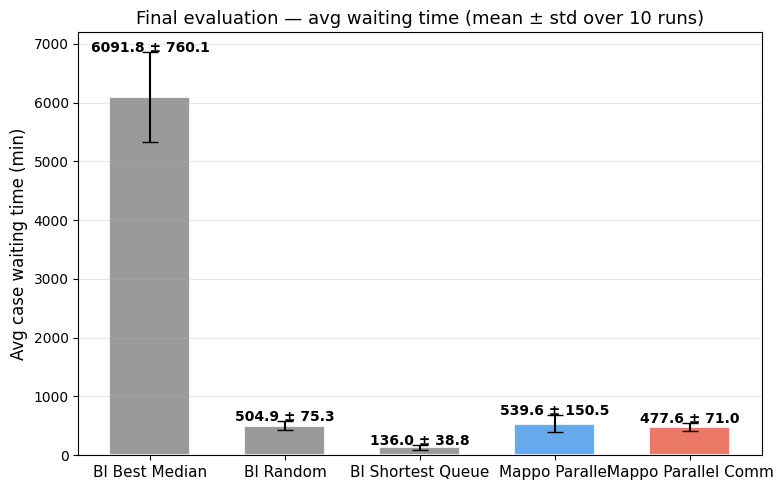

In [ ]:
import matplotlib.pyplot as plt

# ── Per-episode waiting time per methode ──────────────────────────────
episode_data = {}  # {method: [avg_waiting_ep0, avg_waiting_ep1, ...]}

for name, csv_files in methods.items():
    ep_waits = []
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        for col in ["task_assigned_time", "task_started_time"]:
            df[col] = safe_parse_timestamps(df[col])
        df["waiting_min"] = df.apply(calc_seconds, axis=1,
                                      start_col="task_assigned_time", end_col="task_started_time") / 60
        case_wait = df.groupby("case_id")["waiting_min"].sum().mean()
        ep_waits.append(case_wait)
    episode_data[name] = ep_waits

# Auto-assign colors and labels
colors = {}
labels = {}
for name in methods:
    if "baseline" in name:
        colors[name] = "#888888"
    elif "comm" in name:
        colors[name] = "#E8614C"
    else:
        colors[name] = "#4C9BE8"
    labels[name] = name.replace("_", " ").replace("baseline ", "BL ").title()

# ── Choose chart type based on LOG_TYPE ───────────────────────────────
if LOG_TYPE == "train":
    # Learning curve: line chart (episodes are sequential training runs)
    fig, ax = plt.subplots(figsize=(10, 5))
    for name, waits in episode_data.items():
        ax.plot(range(1, len(waits) + 1), waits, marker="o", markersize=4,
                label=labels.get(name, name), color=colors.get(name), linewidth=2)
    ax.set_xlabel("Training episode", fontsize=12)
    ax.set_ylabel("Avg case waiting time (min)", fontsize=12)
    ax.set_title("Learning curve — waiting time per training episode", fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, max(len(w) for w in episode_data.values()) + 1))
else:
    # Evaluation: bar chart with error bars (episodes are independent eval runs)
    fig, ax = plt.subplots(figsize=(8, 5))
    names_ordered = list(episode_data.keys())
    means = [np.mean(episode_data[n]) for n in names_ordered]
    stds = [np.std(episode_data[n]) for n in names_ordered]
    x = range(len(names_ordered))
    bars = ax.bar(x, means, yerr=stds, capsize=6, width=0.6,
                  color=[colors.get(n, "#999") for n in names_ordered],
                  edgecolor="white", linewidth=1.5, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([labels.get(n, n) for n in names_ordered], fontsize=11)
    ax.set_ylabel("Avg case waiting time (min)", fontsize=12)
    ax.set_title(f"Final evaluation — avg waiting time (mean ± std over {len(list(episode_data.values())[0])} runs)", fontsize=13)
    ax.grid(True, alpha=0.3, axis="y")
    # Annotate bars with values
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.3, f"{m:.1f} ± {s:.1f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()